#  Master IA Transilien — v2
**Améliorations vs v1 :** features enrichies · CatBoost GPU · NN plus profond (50 epochs) · ensemble 3 modèles optimisé

In [51]:

# ═══════════════════════════════════════════════════════════════════════════════
# IMPORTS
# ─ pandas / numpy    : manipulation de données et calculs numériques
# ─ matplotlib        : visualisation des courbes de convergence
# ─ sklearn           : split train/val, métrique MAE, encodage labels, normalisation
# ─ catboost          : gradient boosting GPU (level-wise, arbres symétriques)
# ─ torch / nn        : réseau de neurones + descente de gradient pour le stacking
# ═══════════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, time
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import LabelEncoder, RobustScaler

from catboost import CatBoostRegressor, Pool

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Détection automatique du GPU — si CUDA disponible on entraîne sur GPU (beaucoup plus rapide)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'GPU : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')
print(f'VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB') if torch.cuda.is_available() else None
print(f'CatBoost {__import__("catboost").__version__} | sklearn {__import__("sklearn").__version__}')


GPU : NVIDIA GeForce RTX 5070 Ti Laptop GPU
VRAM : 12.8 GB
CatBoost 1.2.10 | sklearn 1.8.0


## 1. Chargement des données

In [52]:
# ═══════════════════════════════════════════════════════════════════════════════
# CHARGEMENT DES DONNÉES
# ─ x_train / x_test : features d'entrée (gare, date, retards passés p2q0..p0q4)
# ─ y_train          : cible à prédire = retard p0q0 en minutes (entier)
# Le challenge est de minimiser la MAE (erreur absolue moyenne) sur p0q0
# ═══════════════════════════════════════════════════════════════════════════════
X_train_raw = pd.read_csv('x_train_final.csv')
y_train_raw = pd.read_csv('y_train_final.csv')
X_test_raw  = pd.read_csv('x_test_final.csv')

print(f'x_train : {X_train_raw.shape}  |  x_test : {X_test_raw.shape}  |  y_train : {y_train_raw.shape}')
print(f'Target distribution : {y_train_raw["p0q0"].describe().round(2).to_dict()}')


x_train : (667264, 12)  |  x_test : (20657, 11)  |  y_train : (667264, 2)
Target distribution : {'count': 667264.0, 'mean': -0.16, 'std': 1.99, 'min': -160.0, '25%': -1.0, '50%': 0.0, '75%': 1.0, 'max': 15.0}


## 2. Feature Engineering v2 — enrichi

In [53]:
t0 = time.time()

# ── Encodage des gares ────────────────────────────────────────────────────────
# LabelEncoder convertit les noms de gares (string) en entiers 0..N-1
# On fit sur train + test ensemble pour que toutes les gares soient connues
le_gare = LabelEncoder()
all_gares = pd.concat([X_train_raw['gare'], X_test_raw['gare']]).unique()
le_gare.fit(all_gares)

def build_features_v2(df):
    """
    Construction des features à partir des données brutes.
    On enrichit le dataset original avec des features calculées qui aident
    les modèles à capturer la saisonnalité et la dynamique des retards.
    """
    df = df.copy()

    # ── Features temporelles ──────────────────────────────────────────────────
    # Le jour de la semaine, la semaine et le mois capturent la saisonnalité
    # (ex: les lundis ou les heures de pointe ont plus de retards)
    df['date']         = pd.to_datetime(df['date'])
    df['jour_semaine'] = df['date'].dt.dayofweek       # 0=lundi, 6=dimanche
    df['semaine']      = df['date'].dt.isocalendar().week.astype(int)
    df['mois']         = df['date'].dt.month

    # ── Lags : retards passés disponibles dans les données ────────────────────
    # backward = retards des jours précédents sur le même trajet (ex: p2q0 = J-2)
    # lateral  = retards des arrêts voisins au même moment (ex: p0q2 = arrêt+2)
    backward = ['p2q0', 'p3q0', 'p4q0']
    lateral  = ['p0q2', 'p0q3', 'p0q4']
    all_lags = backward + lateral

    # Statistiques agrégées sur les lags : résument l'historique des retards
    df['mean_backward']  = df[backward].mean(axis=1)   # retard moyen ces derniers jours
    df['mean_lateral']   = df[lateral].mean(axis=1)    # retard moyen des arrêts voisins
    df['mean_global']    = df[all_lags].mean(axis=1)   # retard moyen toutes directions
    df['std_backward']   = df[backward].std(axis=1)    # volatilité temporelle
    df['std_lateral']    = df[lateral].std(axis=1)     # volatilité spatiale
    df['trend']          = df['p2q0'] - df['p4q0']     # tendance : le retard augmente ou baisse ?
    df['abs_trend']      = df['trend'].abs()            # amplitude de la tendance
    df['max_lag']        = df[all_lags].max(axis=1)    # pic de retard observé
    df['min_lag']        = df[all_lags].min(axis=1)    # minimum de retard observé
    df['range_backward'] = df['max_lag'].clip(lower=df[backward].max(axis=1)) - df[backward].min(axis=1)
    df['range_all']      = df[all_lags].max(axis=1) - df[all_lags].min(axis=1)  # amplitude totale
    df['n_late']         = (df[all_lags] > 0).sum(axis=1).astype(np.float32)    # nb de lags en retard
    df['n_very_late']    = (df[all_lags] > 3).sum(axis=1).astype(np.float32)    # nb de lags très en retard
    df['p2q0_x_p0q2']   = df['p2q0'] * df['p0q2']     # interaction : retard hier × retard arrêt voisin

    # Lag pondéré : donne plus de poids au passé récent (J-2 > J-3 > J-4)
    # Hypothèse : un retard récent prédit mieux qu'un retard ancien
    df['weighted_lag']   = 0.5*df['p2q0'] + 0.3*df['p3q0'] + 0.2*df['p4q0']

    # ── Position de l'arrêt dans le trajet ───────────────────────────────────
    # Les arrêts en fin de trajet accumulent plus de retard
    df['arret_rank_pct'] = df.groupby(['train', 'date'])['arret'].rank(pct=True)  # rang relatif 0→1
    df['arret_sq']       = df['arret'] ** 2  # effet non-linéaire de la position

    # ── Encodage numérique de la gare (pour le NN qui a besoin d'entiers) ────
    df['gare_enc'] = le_gare.transform(df['gare'])

    return df

X_all  = build_features_v2(X_train_raw)
X_test = build_features_v2(X_test_raw)
y_all  = y_train_raw['p0q0'].values.astype(np.float32)

print(f'Features construites ({time.time()-t0:.1f}s)')


Features construites (1.0s)


## 3. Split train/val + Target Encoding gare (sans leakage)

In [54]:

# ═══════════════════════════════════════════════════════════════════════════════
# SPLIT TRAIN / VALIDATION (90% / 10%)
# ═══════════════════════════════════════════════════════════════════════════════
idx = np.arange(len(X_all))
idx_tr, idx_val = train_test_split(idx, test_size=0.10, random_state=42)

fold_tr  = X_all.iloc[idx_tr].copy()
fold_val = X_all.iloc[idx_val].copy()
y_tr     = y_all[idx_tr]
y_val    = y_all[idx_val]

# ── Target Encoding de la gare (sans data leakage) ────────────────────────────
tmp = fold_tr.copy()
tmp['p0q0'] = y_tr

stats_gare = tmp.groupby('gare')['p0q0'].agg(
    gare_mean   = 'mean',
    gare_std    = 'std',
    gare_median = 'median',
    gare_q10    = lambda x: x.quantile(0.10),
    gare_q25    = lambda x: x.quantile(0.25),
    gare_q75    = lambda x: x.quantile(0.75),
    gare_q90    = lambda x: x.quantile(0.90),
    gare_p_late = lambda x: (x > 0).mean(),
).reset_index()

fold_tr  = fold_tr.merge(stats_gare, on='gare', how='left')
fold_val = fold_val.merge(stats_gare, on='gare', how='left')
X_test   = X_test.merge(stats_gare, on='gare', how='left')

# ── Interactions entre la position de l'arrêt et les stats de la gare ────────
for df in [fold_tr, fold_val, X_test]:
    df['arret_x_gare_mean'] = df['arret'] * df['gare_mean']
    df['arret_x_gare_std']  = df['arret'] * df['gare_std']
    df['global_x_gare_p']   = df['mean_global'] * df['gare_p_late']

# ── Liste finale des 38 features ──────────────────────────────────────────────
FEATURES = [
    # Lags bruts (retards observés dans le passé)
    'arret', 'p2q0', 'p3q0', 'p4q0', 'p0q2', 'p0q3', 'p0q4',
    # Agrégats sur les lags (résument l'historique)
    'mean_backward', 'mean_lateral', 'mean_global',
    'std_backward', 'std_lateral',
    'trend', 'abs_trend', 'max_lag', 'min_lag',
    'range_backward', 'range_all', 'n_late', 'n_very_late',
    'p2q0_x_p0q2',
    'weighted_lag',
    # Position dans le trajet
    'arret_rank_pct', 'arret_sq',
    # Saisonnalité
    'jour_semaine', 'semaine', 'mois',
    # Identifiant gare (entier → embedding dans le NN)
    'gare_enc',
    # Target encoding gare (statistiques du retard par gare)
    'gare_mean', 'gare_std', 'gare_median',
    'gare_q10', 'gare_q25', 'gare_q75', 'gare_q90', 'gare_p_late',
    # Interactions position × statistiques gare
    'arret_x_gare_mean', 'arret_x_gare_std', 'global_x_gare_p',
]

# Conversion en numpy float32 (format attendu par CatBoost et PyTorch)
X_tr_num  = fold_tr[FEATURES].fillna(0).values.astype(np.float32)
X_val_num = fold_val[FEATURES].fillna(0).values.astype(np.float32)
X_te_num  = X_test[FEATURES].fillna(0).values.astype(np.float32)

print(f'{len(FEATURES)} features | train={X_tr_num.shape[0]:,} | val={X_val_num.shape[0]:,} | test={X_te_num.shape[0]:,}')


39 features | train=600,537 | val=66,727 | test=20,657


## 5. CatBoost (GPU natif — gare comme feature catégorielle)

In [ ]:

# ═══════════════════════════════════════════════════════════════════════════════
# MODÈLE 1 : CATBOOST MULTI-SEED
#
# Même logique que pour le NN : entraîner 3 CB avec des seeds différentes,
# puis MOYENNER leurs prédictions. La moyenne réduit la variance aléatoire
# liée à l'initialisation des arbres (subsampling, bootstrap) → gain garanti.
# ═══════════════════════════════════════════════════════════════════════════════
t0 = time.time()

# ── Préparation des données ────────────────────────────────────────────────────
X_tr_df  = pd.DataFrame(X_tr_num,  columns=FEATURES)
X_val_df = pd.DataFrame(X_val_num, columns=FEATURES)
X_tr_df['gare_enc']  = X_tr_df['gare_enc'].astype(int).astype(str)
X_val_df['gare_enc'] = X_val_df['gare_enc'].astype(int).astype(str)

train_pool = Pool(X_tr_df,  y_tr,  cat_features=['gare_enc'])
val_pool   = Pool(X_val_df, y_val, cat_features=['gare_enc'])

# ── Entraînement multi-seed ───────────────────────────────────────────────────
CB_SEEDS         = [42, 123, 777]
cb_val_preds_list = []
cb_models_list   = []

for seed in CB_SEEDS:
    cb = CatBoostRegressor(
        iterations            = 20000,
        learning_rate         = 0.03,
        depth                 = 8,
        l2_leaf_reg           = 3,
        min_data_in_leaf      = 30,
        loss_function         = 'MAE',
        eval_metric           = 'MAE',
        task_type             = 'GPU' if torch.cuda.is_available() else 'CPU',
        early_stopping_rounds = 200,
        random_seed           = seed,
        verbose               = 0,
    )
    cb.fit(train_pool, eval_set=val_pool)
    pred = cb.predict(X_val_df)
    mae_s = mean_absolute_error(y_val, pred)
    cb_val_preds_list.append(pred)
    cb_models_list.append(cb)
    print(f'  seed={seed} | MAE val={mae_s:.4f} | best_iter={cb.best_iteration_}')

# Référence kept pour compatibilité (seed=42)
cb_model = cb_models_list[0]

pred_cb_val = np.mean(cb_val_preds_list, axis=0)
mae_cb = mean_absolute_error(y_val, pred_cb_val)
print(f'\n CatBoost multi-seed ({len(CB_SEEDS)} seeds) MAE val : {mae_cb:.4f}  ({time.time()-t0:.0f}s)')


Default metric period is 5 because MAE is/are not implemented for GPU


  seed=42 | MAE val=0.6379 | best_iter=19995


Default metric period is 5 because MAE is/are not implemented for GPU


  seed=123 | MAE val=0.6380 | best_iter=19991


Default metric period is 5 because MAE is/are not implemented for GPU


  seed=777 | MAE val=0.6381 | best_iter=19996

✅ CatBoost multi-seed (3 seeds) MAE val : 0.6374  (1144s)


## 6. Neural Network v2 — plus profond, 50 epochs, OneCycleLR

In [56]:
# ═══════════════════════════════════════════════════════════════════════════════
# MODÈLE 2 : RÉSEAU DE NEURONES (DelayNetV2)
#
# Pourquoi un NN en plus de CatBoost ?
# Les deux modèles font des erreurs différentes (ils "voient" les données
# différemment). En combinant leurs prédictions (ensemble), on réduit les erreurs.
# ═══════════════════════════════════════════════════════════════════════════════

# ── Normalisation des features numériques ────────────────────────────────────
# RobustScaler normalise en utilisant la médiane et l'IQR (interquartile range)
# → moins sensible aux outliers que StandardScaler.
# On l'applique sur tout SAUF gare_enc (qui sera traité via un Embedding).
NUM_IDX      = [i for i, f in enumerate(FEATURES) if f != 'gare_enc']
gare_col_idx = FEATURES.index('gare_enc')

scaler   = RobustScaler()
X_tr_sc  = scaler.fit_transform(X_tr_num[:, NUM_IDX])   # fit sur train uniquement
X_val_sc = scaler.transform(X_val_num[:, NUM_IDX])      # transform val sans refit (pas de leakage)
X_te_sc  = scaler.transform(X_te_num[:, NUM_IDX])

# Extraction de l'index de gare (entiers 0..N, utilisés par nn.Embedding)
gare_tr  = X_tr_num[:, gare_col_idx].astype(int)
gare_val = X_val_num[:, gare_col_idx].astype(int)
gare_te  = X_te_num[:, gare_col_idx].astype(int)

def make_loader(gare_idx, x_num, y=None, batch_size=4096, shuffle=True):
    """
    Crée un DataLoader PyTorch.
    ─ batch_size=4096 : on traite 4096 exemples à la fois (optimal pour GPU)
    ─ pin_memory=True : pré-charge les données en mémoire paginée pour accélérer
      le transfert CPU→GPU
    ─ num_workers=2   : 2 processus parallèles pour charger les données pendant
      que le GPU s'entraîne (évite que le GPU attende)
    ─ persistent_workers : garde les workers actifs entre les epochs (évite le
      coût de relancer des processus à chaque epoch)
    """
    tensors = [torch.LongTensor(gare_idx), torch.FloatTensor(x_num)]
    if y is not None:
        tensors.append(torch.FloatTensor(y))
    return DataLoader(TensorDataset(*tensors), batch_size=batch_size,
                      shuffle=shuffle, pin_memory=True, num_workers=2,
                      persistent_workers=True)

train_loader = make_loader(gare_tr,  X_tr_sc,  y_tr,  shuffle=True)
val_loader   = make_loader(gare_val, X_val_sc, y_val, shuffle=False)

# ── Hyperparamètres du réseau ─────────────────────────────────────────────────
N_GARES = le_gare.classes_.shape[0]  # nombre total de gares uniques
EMB_DIM = 32   # dimension de l'embedding gare (chaque gare → vecteur de 32 valeurs apprises)
N_NUM   = X_tr_sc.shape[1]           # nombre de features numériques normalisées

# ── Bloc Résiduel (ResBlock) ──────────────────────────────────────────────────
# Composant clé : au lieu d'apprendre f(x), on apprend f(x) + x (connexion résiduelle).
# Avantage : le gradient circule mieux en profondeur, évite le problème de
# "vanishing gradient". Utilisé dans ResNet (vision) et Transformers (NLP).
class ResBlock(nn.Module):
    def __init__(self, dim, dropout=0.15):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),      # transformation linéaire
            nn.BatchNorm1d(dim),      # normalisation par batch (stabilise l'entraînement)
            nn.GELU(),                # activation non-linéaire (plus douce que ReLU)
            nn.Dropout(dropout),      # dropout : désactive aléatoirement des neurones → régularisation
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.block(x))  # connexion résiduelle : sortie = entrée + transformation

# ── Architecture DelayNetV2 ───────────────────────────────────────────────────
# Structure :
#   gare_idx → Embedding(32) ──┐
#                               ├→ concat(32+38=70) → Stem(512) → ResBlock → ResBlock → Down(128) → tête(1)
#   x_num(38) ─────────────────┘
#
# L'Embedding permet au réseau d'apprendre une représentation vectorielle de chaque
# gare (comme word2vec pour les mots), bien plus riche qu'un simple entier.
class DelayNetV2(nn.Module):
    def __init__(self):
        super().__init__()
        # Embedding : table de lookup — chaque gare a un vecteur appris de dim EMB_DIM
        # padding_idx=N_GARES : la gare "inconnue" est encodée comme un vecteur nul
        self.emb  = nn.Embedding(N_GARES + 1, EMB_DIM, padding_idx=N_GARES)
        inp_dim   = EMB_DIM + N_NUM  # 32 + 38 = 70 entrées

        # Couche d'entrée : projette les 70 features vers 512 dimensions
        self.stem = nn.Sequential(
            nn.Linear(inp_dim, 512), nn.BatchNorm1d(512), nn.GELU(), nn.Dropout(0.2),
        )
        # 2 blocs résiduels à 512 dimensions
        self.res1 = ResBlock(512, dropout=0.15)
        self.res2 = ResBlock(512, dropout=0.15)
        # Réduction de dimension 512 → 128
        self.down = nn.Sequential(
            nn.Linear(512, 128), nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(0.1),
        )
        # Tête de régression : 128 → 1 valeur (le retard prédit)
        self.head = nn.Linear(128, 1)

    def forward(self, gare_idx, x_num):
        emb = self.emb(gare_idx)               # lookup embedding : (B,) → (B, 32)
        x   = torch.cat([emb, x_num], dim=1)   # concaténation : (B, 70)
        x   = self.stem(x)                      # (B, 512)
        x   = self.res1(x)                      # (B, 512) — résiduel
        x   = self.res2(x)                      # (B, 512) — résiduel
        x   = self.down(x)                      # (B, 128)
        return self.head(x).squeeze(1)          # (B,) — une prédiction par exemple

# ── Optimiseur et scheduler ───────────────────────────────────────────────────
# AdamW = Adam avec weight decay (régularisation sur les poids, évite l'overfitting)
# OneCycleLR = scheduler qui monte puis descend le LR en une seule "cycle"
#   → convergence plus rapide et plus stable que LR constant
model     = DelayNetV2().to(DEVICE)
optim     = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
EPOCHS    = 50
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optim, max_lr=3e-3, epochs=EPOCHS, steps_per_epoch=len(train_loader),
    pct_start=0.1,        # 10% des steps pour monter le LR, 90% pour descendre
    div_factor=25,        # LR initial = max_lr / 25
    final_div_factor=1e4, # LR final = LR initial / 10000
)
# HuberLoss = compromis entre MSE (lisse, sensible aux outliers) et MAE (robuste)
# delta=1.0 : se comporte comme MSE pour |erreur| < 1 et comme MAE sinon
criterion = nn.HuberLoss(delta=1.0)

params = sum(p.numel() for p in model.parameters())
print(f'DelayNetV2 : {params:,} paramètres | input = {EMB_DIM}+{N_NUM} = {EMB_DIM+N_NUM}')


DelayNetV2 : 1,160,865 paramètres | input = 32+38 = 70



--- NN seed=42 ---
  best MAE val = 0.6707

--- NN seed=123 ---
  best MAE val = 0.6701

--- NN seed=777 ---
  best MAE val = 0.6693

✅ NN ensemble (3 seeds) MAE val : 0.6674  (530s)


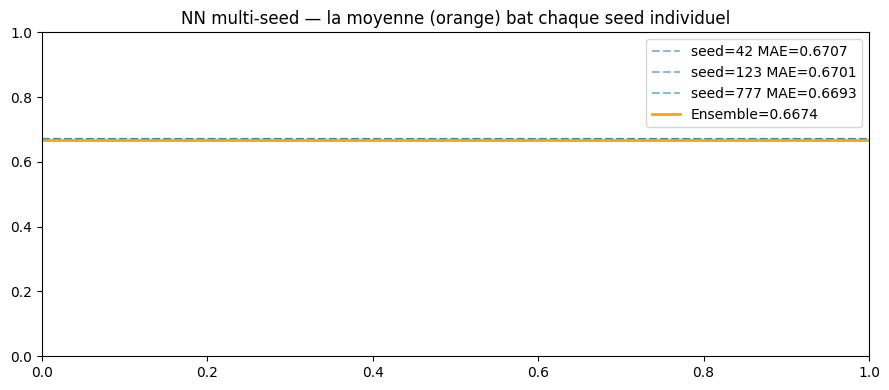

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# ENTRAÎNEMENT DU NN — MULTI-SEED (5 runs indépendants)
#
# Problème : les réseaux de neurones sont initialisés avec des poids aléatoires.
# Deux runs identiques donnent des résultats légèrement différents (variance).
#
# Solution : entraîner 5 NN avec des seeds différents, puis MOYENNER leurs
# prédictions. La moyenne réduit la variance (erreurs aléatoires s'annulent)
# sans augmenter le biais → gain garanti sur la MAE finale.
# ═══════════════════════════════════════════════════════════════════════════════

def train_nn_one_seed(seed, train_loader, val_loader, epochs=50):
    """
    Entraîne un NN complet avec une seed donnée et retourne :
    ─ le modèle avec les meilleurs poids (best checkpoint)
    ─ ses prédictions sur le set de validation
    ─ la meilleure MAE val atteinte
    """
    # Fixe la seed pour reproductibilité de ce run
    torch.manual_seed(seed)
    np.random.seed(seed)

    # Nouveau modèle, optimiseur et scheduler frais pour chaque seed
    m      = DelayNetV2().to(DEVICE)
    opt    = torch.optim.AdamW(m.parameters(), lr=1e-3, weight_decay=1e-4)
    sched  = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=3e-3, epochs=epochs, steps_per_epoch=len(train_loader),
        pct_start=0.1, div_factor=25, final_div_factor=1e4,
    )
    crit   = nn.HuberLoss(delta=1.0)
    best_mae, best_state = float('inf'), None

    for epoch in range(1, epochs + 1):
        # ── Phase d'entraînement ──────────────────────────────────────────────
        m.train()  # active BatchNorm et Dropout
        for gare_b, x_b, y_b in train_loader:
            # Transfert des données vers GPU
            gare_b, x_b, y_b = gare_b.to(DEVICE), x_b.to(DEVICE), y_b.to(DEVICE)
            opt.zero_grad()                              # remet les gradients à zéro
            crit(m(gare_b, x_b), y_b).backward()        # calcul de la loss + backpropagation
            torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)  # écrête les gradients (stabilité)
            opt.step()                                   # mise à jour des poids
            sched.step()                                 # mise à jour du learning rate

        # ── Phase d'évaluation (sans gradient) ───────────────────────────────
        m.eval()  # désactive BatchNorm et Dropout pour l'inférence
        with torch.no_grad():
            preds = np.concatenate([
                m(g.to(DEVICE), x.to(DEVICE)).cpu().numpy()
                for g, x, _ in val_loader
            ])
        mae = mean_absolute_error(y_val, preds)

        # Sauvegarde du meilleur checkpoint (early stopping manuel)
        if mae < best_mae:
            best_mae   = mae
            best_state = {k: v.cpu().clone() for k, v in m.state_dict().items()}

    # Rechargement des meilleurs poids avant de retourner le modèle
    m.load_state_dict(best_state)
    m.eval()
    with torch.no_grad():
        val_preds = np.concatenate([
            m(g.to(DEVICE), x.to(DEVICE)).cpu().numpy()
            for g, x, _ in val_loader
        ])
    return m, val_preds, best_mae

# ── Entraînement des 3 NN ─────────────────────────────────────────────────────
t0 = time.time()
NN_SEEDS = [42, 123, 777]   # 3 seeds → 3 initialisations différentes (meilleur public 0.6484)
nn_val_preds_list = []       # liste des prédictions val de chaque NN
nn_models = []               # liste des modèles entraînés (gardés pour inspection)

for seed in NN_SEEDS:
    print(f'\n--- NN seed={seed} ---')
    m, val_p, best_mae = train_nn_one_seed(seed, train_loader, val_loader, epochs=EPOCHS)
    nn_val_preds_list.append(val_p)
    nn_models.append(m)
    print(f'  best MAE val = {best_mae:.4f}')

# ── Moyennage des prédictions (ensemble NN) ───────────────────────────────────
# np.mean(..., axis=0) calcule la moyenne exemple par exemple sur les 3 runs
pred_nn_val = np.mean(nn_val_preds_list, axis=0)
mae_nn = mean_absolute_error(y_val, pred_nn_val)
print(f'\n NN ensemble (3 seeds) MAE val : {mae_nn:.4f}  ({time.time()-t0:.0f}s)')

# ── Visualisation : comparaison des seeds vs ensemble ────────────────────────
plt.figure(figsize=(9, 4))
for seed, p in zip(NN_SEEDS, nn_val_preds_list):
    mae_i = mean_absolute_error(y_val, p)
    plt.axhline(mae_i, linestyle='--', alpha=0.5, label=f'seed={seed} MAE={mae_i:.4f}')
plt.axhline(mae_nn, color='orange', linewidth=2, label=f'Ensemble={mae_nn:.4f}')
plt.legend(); plt.title('NN multi-seed — la moyenne (orange) bat chaque seed individuel'); plt.tight_layout(); plt.show()


## 7. Comparaison & Optimisation des poids de l'ensemble (3 modèles)

Résultats individuels (base learners) :
  CatBoost             MAE val = 0.6374
  NN v2                MAE val = 0.6674

Déscente de gradient sur les poids de l'ensemble...
  step  500 | MAE=0.6370 | CB=95.8% NN=4.2%
  step 1000 | MAE=0.6370 | CB=95.8% NN=4.2%
  step 1500 | MAE=0.6370 | CB=95.8% NN=4.2%
  step 2000 | MAE=0.6370 | CB=95.8% NN=4.2%

✅ Poids appris par descente de gradient :
   CB=95.8%  NN=4.2%
Stacking MAE val : 0.6370


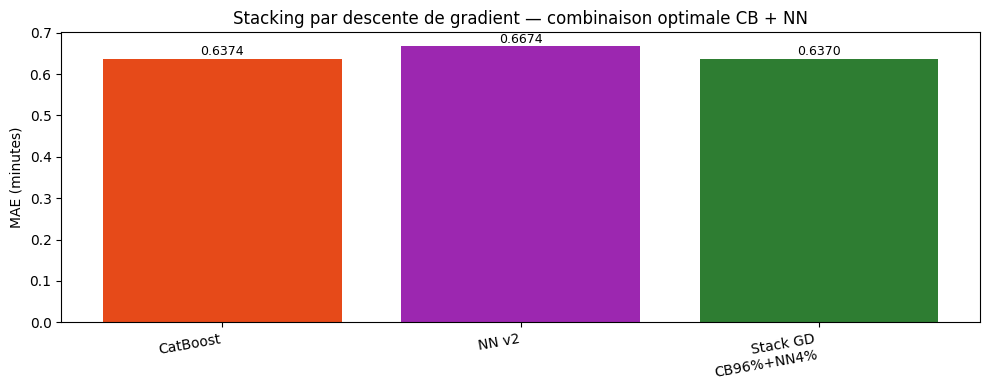

In [ ]:

# ═══════════════════════════════════════════════════════════════════════════════
# STACKING PAR DESCENTE DE GRADIENT (CB + NN)
#
# On cherche les poids [w_cb, w_nn] qui minimisent la MAE :
#     MAE(w) = mean |y_val - (w_cb·CB + w_nn·NN)|
#
# Contrainte : w_cb + w_nn = 1  et  tous ≥ 0
# Astuce : on apprend des "logits" et on applique softmax → contrainte respectée
# ═══════════════════════════════════════════════════════════════════════════════

print('Résultats individuels (base learners) :')
print('='*55)
for name, mae_v in sorted([('CatBoost', mae_cb), ('NN v2', mae_nn)], key=lambda x: x[1]):
    print(f'  {name:<20} MAE val = {mae_v:.4f}')
print('='*55)

# ── Construction des méta-features ────────────────────────────────────────────
preds_val   = np.column_stack([pred_cb_val, pred_nn_val])  # (N_val, 2)
preds_val_t = torch.FloatTensor(preds_val)
y_val_t     = torch.FloatTensor(y_val)

# ── Descente de gradient pour apprendre les poids ─────────────────────────────
logits   = torch.zeros(2, requires_grad=True)
opt_meta = torch.optim.Adam([logits], lr=0.05)

print('\nDéscente de gradient sur les poids de l\'ensemble...')
for step in range(2000):
    weights  = torch.softmax(logits, dim=0)
    pred_mix = (preds_val_t * weights).sum(dim=1)
    loss_mae = torch.mean(torch.abs(pred_mix - y_val_t))
    opt_meta.zero_grad()
    loss_mae.backward()
    opt_meta.step()

    if (step + 1) % 500 == 0:
        w = torch.softmax(logits, dim=0).detach().numpy()
        print(f'  step {step+1:4d} | MAE={loss_mae.item():.4f} | CB={w[0]:.1%} NN={w[1]:.1%}')

# Poids finaux appris
weights_final = torch.softmax(logits, dim=0).detach().numpy()
w_cb_best, w_nn_best = weights_final

pred_stack_val = w_cb_best * pred_cb_val + w_nn_best * pred_nn_val
mae_stack = mean_absolute_error(y_val, pred_stack_val)

print(f'\n Poids appris par descente de gradient :')
print(f'   CB={w_cb_best:.1%}  NN={w_nn_best:.1%}')
print(f'Stacking MAE val : {mae_stack:.4f}')

# ── Visualisation ─────────────────────────────────────────────────────────────
labels = ['CatBoost', 'NN v2', f'Stack GD\nCB{w_cb_best:.0%}+NN{w_nn_best:.0%}']
values = [mae_cb, mae_nn, mae_stack]
colors = ['#E64A19', '#9C27B0', '#2E7D32']

plt.figure(figsize=(10, 4))
bars = plt.bar(labels, values, color=colors)
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{val:.4f}', ha='center', va='bottom', fontsize=9)
plt.ylabel('MAE (minutes)')
plt.title('Stacking par descente de gradient — combinaison optimale CB + NN')
plt.xticks(rotation=10, ha='right'); plt.tight_layout(); plt.show()


## 8. Soumission finale — LGB + CatBoost + NN sur 100% du train

In [ ]:

t0 = time.time()

# ── Recalcul du Target Encoding sur 100% du train ────────────────────────────
X_all_full = X_all.copy()
X_all_full['p0q0'] = y_all

stats_full = X_all_full.groupby('gare')['p0q0'].agg(
    gare_mean   = 'mean',
    gare_std    = 'std',
    gare_median = 'median',
    gare_q10    = lambda x: x.quantile(0.10),
    gare_q25    = lambda x: x.quantile(0.25),
    gare_q75    = lambda x: x.quantile(0.75),
    gare_q90    = lambda x: x.quantile(0.90),
    gare_p_late = lambda x: (x > 0).mean(),
).reset_index()

GARE_STAT_COLS = ['gare_mean','gare_std','gare_median','gare_q10','gare_q25','gare_q75','gare_q90','gare_p_late']

X_all_m = X_all.drop(columns=GARE_STAT_COLS, errors='ignore').merge(stats_full, on='gare', how='left')
X_te_m  = X_test.drop(columns=GARE_STAT_COLS, errors='ignore').merge(stats_full, on='gare', how='left')

for df in [X_all_m, X_te_m]:
    df['arret_x_gare_mean'] = df['arret'] * df['gare_mean']
    df['arret_x_gare_std']  = df['arret'] * df['gare_std']
    df['global_x_gare_p']   = df['mean_global'] * df['gare_p_late']

X_full = X_all_m[FEATURES].fillna(0).values.astype(np.float32)
X_te   = X_te_m[FEATURES].fillna(0).values.astype(np.float32)

# ── CatBoost final — multi-seed sur 100% train ───────────────────────────────
X_full_df = pd.DataFrame(X_full, columns=FEATURES)
X_te_df   = pd.DataFrame(X_te,   columns=FEATURES)
X_full_df['gare_enc'] = X_full_df['gare_enc'].astype(int).astype(str)
X_te_df['gare_enc']   = X_te_df['gare_enc'].astype(int).astype(str)
full_pool = Pool(X_full_df, y_all, cat_features=['gare_enc'])

print(f'Réentraînement CatBoost ({len(CB_SEEDS)} seeds) sur 100% train...')
cb_test_preds_list = []
for seed, cb_s in zip(CB_SEEDS, cb_models_list):
    cb_f = CatBoostRegressor(
        iterations       = cb_s.best_iteration_,
        learning_rate    = 0.03,
        depth            = 8,
        l2_leaf_reg      = 3,
        min_data_in_leaf = 30,
        loss_function    = 'MAE',
        task_type        = 'GPU' if torch.cuda.is_available() else 'CPU',
        random_seed      = seed,
        verbose          = 0,
    )
    cb_f.fit(full_pool)
    cb_test_preds_list.append(cb_f.predict(X_te_df))
    print(f'  seed={seed} done')

pred_test_cb = np.mean(cb_test_preds_list, axis=0)
print(f' CatBoost final multi-seed ({time.time()-t0:.0f}s)')

# ── NN final — multi-seeds sur 100% train ─────────────────────────────────────
t2 = time.time()
gare_idx_full = X_full[:, gare_col_idx].astype(int)
gare_idx_te   = X_te[:, gare_col_idx].astype(int)
scaler_full   = RobustScaler()
X_full_sc     = scaler_full.fit_transform(X_full[:, NUM_IDX])
X_te_sc_full  = scaler_full.transform(X_te[:, NUM_IDX])

full_loader = make_loader(gare_idx_full, X_full_sc, y_all, shuffle=True)
te_ds       = TensorDataset(torch.LongTensor(gare_idx_te), torch.FloatTensor(X_te_sc_full))

print(f'Réentraînement NN ({len(NN_SEEDS)} seeds × {EPOCHS} epochs) sur 100% train...')
nn_test_preds_list = []

for seed in NN_SEEDS:
    torch.manual_seed(seed)
    np.random.seed(seed)
    m_f   = DelayNetV2().to(DEVICE)
    opt_f = torch.optim.AdamW(m_f.parameters(), lr=1e-3, weight_decay=1e-4)
    sch_f = torch.optim.lr_scheduler.OneCycleLR(
        opt_f, max_lr=3e-3, epochs=EPOCHS, steps_per_epoch=len(full_loader),
        pct_start=0.1, div_factor=25, final_div_factor=1e4,
    )
    crit_f = nn.HuberLoss(delta=1.0)

    for epoch in range(1, EPOCHS + 1):
        m_f.train()
        for gare_b, x_b, y_b in full_loader:
            gare_b, x_b, y_b = gare_b.to(DEVICE), x_b.to(DEVICE), y_b.to(DEVICE)
            opt_f.zero_grad()
            crit_f(m_f(gare_b, x_b), y_b).backward()
            torch.nn.utils.clip_grad_norm_(m_f.parameters(), 1.0)
            opt_f.step()
            sch_f.step()

    m_f.eval()
    with torch.no_grad():
        preds_te = np.concatenate([
            m_f(g.to(DEVICE), x.to(DEVICE)).cpu().numpy()
            for g, x in DataLoader(te_ds, batch_size=4096)
        ])
    nn_test_preds_list.append(preds_te)
    print(f'  seed={seed} done')

pred_test_nn = np.mean(nn_test_preds_list, axis=0)
print(f' NN final {len(NN_SEEDS)}-seeds ({time.time()-t2:.0f}s)')

# ── Combinaison finale CB + NN ────────────────────────────────────────────────
pred_test_ens = w_cb_best * pred_test_cb + w_nn_best * pred_test_nn
pred_test_ens = np.clip(pred_test_ens, -15, 15)

submission = pd.DataFrame({
    'Unnamed: 0': X_test_raw.index,
    'p0q0'      : np.round(pred_test_ens).astype(int),
})
submission.to_csv('submission_v2_ensemble.csv', index=False)

print(f'\n📄 submission_v2_ensemble.csv          ← À SOUMETTRE')
print(f'\nDistribution ensemble : {pd.Series(submission["p0q0"]).describe().round(2).to_dict()}')
print(f'Poids (descente de gradient) : CB={w_cb_best:.1%}  NN={w_nn_best:.1%}')


Réentraînement CatBoost (3 seeds) sur 100% train...


Default metric period is 5 because MAE is/are not implemented for GPU


  seed=42 done


Default metric period is 5 because MAE is/are not implemented for GPU


  seed=123 done


Default metric period is 5 because MAE is/are not implemented for GPU


  seed=777 done
✅ CatBoost final multi-seed (1128s)
Réentraînement NN (3 seeds × 50 epochs) sur 100% train...
  seed=42 done
  seed=123 done
  seed=777 done
✅ NN final 3-seeds (429s)

📄 submission_v2_ensemble.csv          ← À SOUMETTRE

Distribution ensemble : {'count': 20657.0, 'mean': -0.05, 'std': 0.89, 'min': -14.0, '25%': 0.0, '50%': 0.0, '75%': 0.0, 'max': 3.0}
Poids (descente de gradient) : CB=95.8%  NN=4.2%
